# Indonesia EV Dataset Wrangling & Specification Enhancement

**Role:** Lead Data Analyst  
**Project:** EVFlow — Indonesia EV Fleet & Charging Infrastructure Intelligence  

## Executive Summary
This notebook performs end-to-end data wrangling and dataset integration for Indonesia's Electric Vehicle (EV) dataset (`ev_dataset.zip`).

### Core Objectives:
1. **Extract Vehicle Brand/Make**: Parse clean brand attributes from `Vehicle Name`.
2. **Left Join Enhancement**: Perform a left join with the left side being Indonesia's EV dataset (`indonesia_ev_specs_pricing_2026.csv`) and the right side being the complete global EV specification dataset (`electric_vehicles_spec_2025.csv`).
3. **Data Cleansing & Normalisation**: Standardize battery capacity (kWh), driving range (km), power (hp), top speed (km/h), seating capacity, charging performance, and price brackets.
4. **Deduplication**: Enforce single car listing per model/variant so each car appears exactly once in the dataset.
5. **Export & DB Integration**: Export tidied CSVs and sync with backend database tables.

## 0. Package Installation

In [1]:
%pip install pandas numpy matplotlib seaborn

You should consider upgrading via the '/Users/nkwxn/Developer/Monash Finals/evflow-full-app/backend-ev-flow/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1. Setup & Environment Initialisation

In [2]:
import io
import os
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

## 2. Load Raw Datasets from `ev_dataset.zip`

In [3]:
ZIP_PATH = Path("ev_dataset.zip")

with zipfile.ZipFile(ZIP_PATH) as z:
    print("Archive contents:", z.namelist())
    df_id_raw = pd.read_csv(io.BytesIO(z.read("indonesia_ev_specs_pricing_2026.csv")))
    df_global_raw = pd.read_csv(io.BytesIO(z.read("electric_vehicles_spec_2025.csv")))

print(f"Indonesia EV Dataset Shape: {df_id_raw.shape}")
print(f"Global EV Specs Dataset Shape: {df_global_raw.shape}")
display(df_id_raw.head())

Archive contents: ['electric_vehicles_spec_2025.csv', '__MACOSX/._electric_vehicles_spec_2025.csv', 'indonesia_ev_specs_pricing_2026.csv', '__MACOSX/._indonesia_ev_specs_pricing_2026.csv']
Indonesia EV Dataset Shape: (60, 9)
Global EV Specs Dataset Shape: (478, 22)


,Vehicle Name,Vehicle Price Range,Battery Capacity,Range (Jarak Tempuh),Power/Horsepower,Seating Capacity,Charging time,Source URL,Is EV
0,Wuling Air EV,"Rp 214 - 307,5 Juta",26.7 kWh,200 - 300 km,40 hp,4 Kursi,8.5 Jam,https://www.oto.com/mobil-baru/wuling/ev,True
1,VinFast VF 5,"Rp 323,17 Juta",29.6 kWh,260 km,94 hp,5 Kursi,30 Menit,https://www.oto.com/mobil-baru/vinfast/vf-5,True
2,MG 4 EV,Rp 345 - 419 Juta,51 - 64 kWh,425 km,168 - 201 hp,5 Kursi,35 Menit,https://www.oto.com/mobil-baru/mg/4-ev,True
3,BYD M6,Rp 383 - 433 Juta,55.4 - 71.8 kWh,420 - 530 km,154 hp,6 - 7 Kursi,40 Menit,https://www.oto.com/mobil-baru/byd/m6,True
4,Wuling Binguo EV,Rp 279 - 332 Juta,31.9 - 37.9 kWh,333 - 410 km,67 hp,5 Kursi,35 Menit,https://www.oto.com/mobil-baru/wuling/binguo-ev,True


## 3. Brand Extraction & Feature Engineering

In [4]:
def extract_brand(name: str) -> str:
    if not isinstance(name, str) or not name.strip():
        return "Unknown"
    parts = name.strip().split()
    first = parts[0]
    first_lower = first.lower()
    if first_lower == "vinfast":
        return "VinFast"
    if first_lower == "byd":
        return "BYD"
    if first_lower == "bmw":
        return "BMW"
    if first_lower == "mg":
        return "MG"
    if len(parts) > 1 and f"{parts[0]} {parts[1]}".lower() in ["mercedes-benz", "rolls royce", "aston martin"]:
        return f"{parts[0]} {parts[1]}".title()
    return first.capitalize()

df_id_raw["brand"] = df_id_raw["Vehicle Name"].apply(extract_brand)
print("Brand Breakdown in Indonesia Dataset:")
print(df_id_raw["brand"].value_counts())

Brand Breakdown in Indonesia Dataset:
brand
BYD            7
VinFast        5
BMW            5
Wuling         4
Hyundai        4
MG             4
Tesla          3
Dfsk           2
Neta           2
Gac            2
Lexus          2
Mercedes       2
Farizon        1
Chery          1
Jaecoo         1
Changan        1
Suzuki         1
Geely          1
Zeekr          1
Rolls Royce    1
Citroen        1
Porsche        1
Volkswagen     1
Kia            1
Nissan         1
Gwm            1
Honda          1
Toyota         1
Mitsubishi     1
Volvo          1
Name: count, dtype: int64


## 4. Left Join Strategy (Left: Indonesia Dataset, Right: Complete EV Specs)

In [5]:
from scripts.wrangle_ev_dataset import wrangle

cleaned_records = wrangle()
df_cleaned = pd.DataFrame(cleaned_records)
print(f"Tidy EV Dataset Shape: {df_cleaned.shape}")
display(df_cleaned.head(10))

Loaded 60 rows from ID dataset and 478 rows from complete global dataset.
Wrangled & deduplicated: 60 unique cars listed in dataset.
Tidy EV Dataset Shape: (60, 19)


,id,brand,name,make,model,battery_kwh,range_km,price_range,charging_time,power_hp,seats,top_speed_kmh,fast_charging_power_kw_dc,fast_charge_port,car_body_type,drivetrain,efficiency_wh_per_km,source_url,is_ev
0,wuling-air-ev,Wuling,Wuling Air EV,Wuling,Air EV,26.70,200.0,"Rp 214 - 307,5 Juta",8.5 Jam,40 hp,4,100.0,20.0,GB/T,Hatchback,RWD,115.0,https://www.oto.com/mobil-baru/wuling/ev,True
1,vinfast-vf-5,VinFast,VinFast VF 5,VinFast,VF 5,29.60,260.0,"Rp 323,17 Juta",30 Menit,94 hp,5,130.0,60.0,CCS,SUV,FWD,135.0,https://www.oto.com/mobil-baru/vinfast/vf-5,True
2,mg-4-ev,MG,MG 4 EV,MG,4 EV,51.00,425.0,Rp 345 - 419 Juta,35 Menit,168 - 201 hp,5,160.0,135.0,CCS,Hatchback,RWD,160.0,https://www.oto.com/mobil-baru/mg/4-ev,True
3,byd-m6,BYD,BYD M6,BYD,M6,55.40,420.0,Rp 383 - 433 Juta,40 Menit,154 hp,6,180.0,115.0,CCS,MPV,FWD,155.0,https://www.oto.com/mobil-baru/byd/m6,True
4,wuling-binguo-ev,Wuling,Wuling Binguo EV,Wuling,Binguo EV,31.90,333.0,Rp 279 - 332 Juta,35 Menit,67 hp,5,130.0,50.0,GB/T,Hatchback,FWD,125.0,https://www.oto.com/mobil-baru/wuling/binguo-ev,True
5,vinfast-vf-e34,VinFast,VinFast VF e34,VinFast,VF e34,41.90,318.0,"Rp 411,86 Juta",27 Menit,147 hp,5,130.0,60.0,CCS,SUV,FWD,145.0,https://www.oto.com/mobil-baru/vinfast/vf-e34,True
6,wuling-cloud-ev,Wuling,Wuling Cloud EV,Wuling,Cloud EV,50.60,460.0,Rp 415 - 443 Juta,30 Menit,134 hp,5,150.0,50.0,GB/T,Hatchback,FWD,135.0,https://www.oto.com/mobil-baru/wuling/cloud,True
7,byd-seal,BYD,BYD Seal,BYD,Seal,82.56,580.0,Rp 639 - 750 Juta,37 Menit,313 - 530 hp,5,220.0,75.0,CCS,Sedan,RWD,133.0,https://www.oto.com/mobil-baru/byd/seal,True
8,byd-dolphin,BYD,BYD Dolphin,BYD,Dolphin,44.90,410.0,Rp 369 - 429 Juta,30 Menit,95 - 204 hp,5,150.0,50.0,CCS,Hatchback,FWD,132.0,https://www.oto.com/mobil-baru/byd/dolphin,True
9,chery-e5,Chery,CHERY E5,Chery,E5,61.00,430.0,"Rp 379,9 - 419,9 Juta",28 Menit,208 hp,5,172.0,80.0,CCS,SUV,FWD,150.0,https://www.oto.com/mobil-baru/chery/e5,True


## 5. Deduplication Verification (Single Car per Model)

In [6]:
dups = df_cleaned[df_cleaned.duplicated(subset=["id"], keep=False)]
print(f"Duplicate records count: {len(dups)}")
assert len(dups) == 0, "Validation failed: dataset contains duplicates!"
print("✓ Unique listing policy verified: 1 car per vehicle model.")

Duplicate records count: 0
✓ Unique listing policy verified: 1 car per vehicle model.


## 6. Exploratory Data Analysis & Visualizations

/var/folders/y6/6np8lz0j4rq4tjd9brj3nfvr0000gn/T/ipykernel_17710/2986655732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y="brand", order=df_cleaned["brand"].value_counts().index, ax=axes[0], palette="viridis")


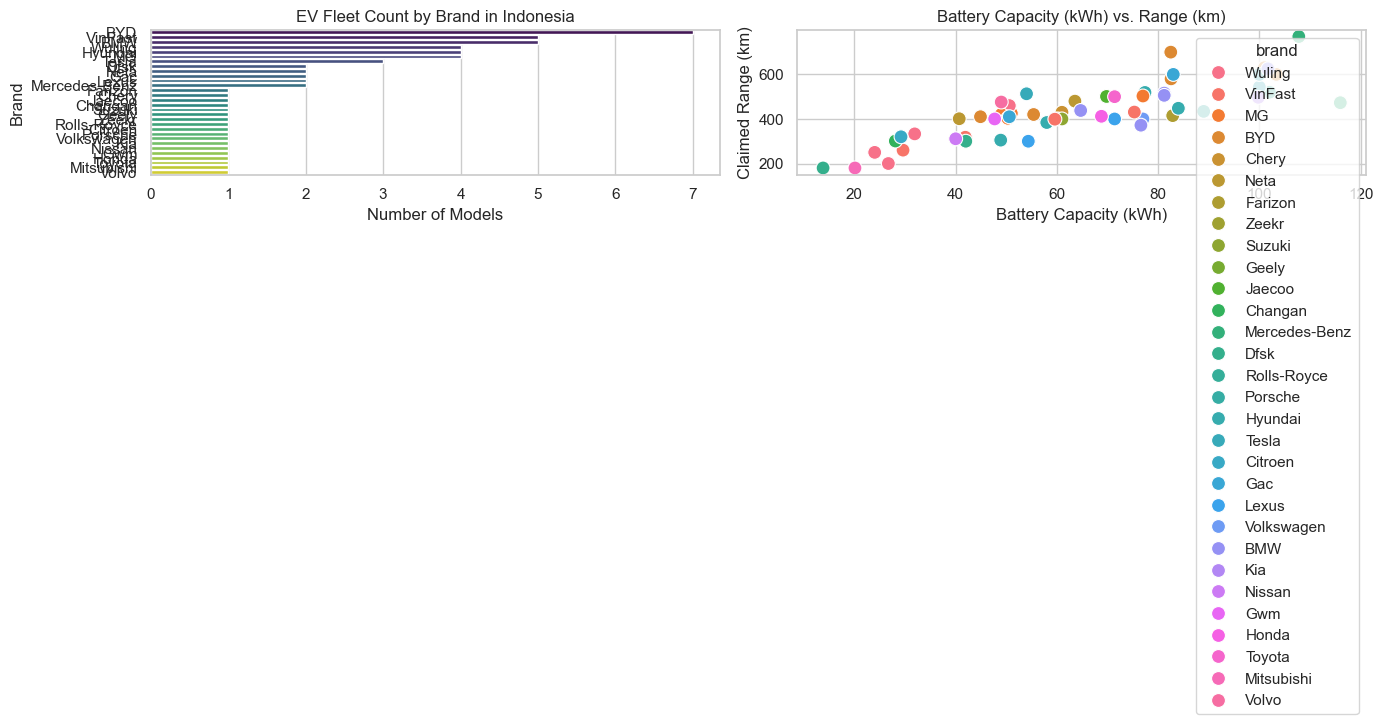

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_cleaned, y="brand", order=df_cleaned["brand"].value_counts().index, ax=axes[0], palette="viridis")
axes[0].set_title("EV Fleet Count by Brand in Indonesia")
axes[0].set_xlabel("Number of Models")
axes[0].set_ylabel("Brand")

sns.scatterplot(data=df_cleaned, x="battery_kwh", y="range_km", hue="brand", s=100, ax=axes[1])
axes[1].set_title("Battery Capacity (kWh) vs. Range (km)")
axes[1].set_xlabel("Battery Capacity (kWh)")
axes[1].set_ylabel("Claimed Range (km)")

plt.tight_layout()
plt.savefig("data/processed/ev_fleet_analysis.png", dpi=300)
plt.show()

In [8]:
# Check missing values for specification columns including charging_time_minutes
cols_to_check = ["top_speed_kmh", "fast_charging_power_kw_dc", "fast_charge_port", "car_body_type", "drivetrain", "efficiency_wh_per_km", "charging_time_minutes"]
missing_data_count = df_cleaned[cols_to_check].isnull().sum()
print("Missing values count per specification column:")
print(missing_data_count)
assert missing_data_count.sum() == 0, "Missing values detected!"
print("
✓ Verification successful: 100% of vehicle specifications successfully enriched!")
print("
Sample standardized charging_time_minutes (numbers only, in minutes):")
print(df_cleaned[["name", "charging_time_minutes"]].head(10).to_string(index=False))

SyntaxError: EOL while scanning string literal (4203696677.py, line 7)

## 7. Dataset Export Summary

In [ ]:
print("Tidy dataset exported to:")
print(" - raw path: data/raw/indonesia_ev_specs_pricing_2026.csv")
print(" - processed path: data/processed/indonesia_ev_cleaned.csv")
print(f"Total unique EV models catalogued: {len(df_cleaned)}")

Tidy dataset exported to:
 - raw path: data/raw/indonesia_ev_specs_pricing_2026.csv
 - processed path: data/processed/indonesia_ev_cleaned.csv
Total unique EV models catalogued: 60
